# Probe Guidance: Exploring the Cross Entropy Method

The cross entropy method (CEM) is what enables the VJEPA2 AC predictor architecture to perform planning. Thus making enabling it to become a world model (imagining actions and their consequences on the environment) that can be deployed in a real world task (robot manipulation, probe guidance, etc.)

We want to know how well this world modeling approach works from two perspectives: time and error. We need to know how long it takes the world model to do a single inference step, and how much error is in it's predictions. Besides raw performance of the predictor (we could even assume a perfect predictor), There are several parameters that have control over the inference time and error of the world model, namely the number of CEM steps, rollout steps, and samples.

To get a good idea of which sets of parameters work best, the `cem_hyperparameter_grid_search.py` file enables us to find good configurations over a validaton set. The best set of parameters should result in short inference times and low error between predicted actions and ground truth actions, and ideally also work well on an unseen test set.

## CEM Hyperparameter Grid Search Results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Set notebook display preferences
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
hyperparameter_search_results_csv = "hyperparameter_search_outputs/2026-08-19_22-39-56/hyperparameter_search_results.csv"

### Basic Tables

In [4]:
df_results = pd.read_csv(hyperparameter_search_results_csv)

In [5]:
df_results.sort_values(by="mean_rep_l1_error", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
47,2,15,10,20,3768.599085,3.491048,0.450200,0.027189,0.066019,0.023023
40,2,15,5,5,1031.459725,3.206932,0.450577,0.026167,0.077945,0.032918
17,1,15,10,10,691.162508,1.911931,0.450614,0.031780,0.046450,0.018956
43,2,15,5,20,3766.280302,2.341415,0.450975,0.027024,0.083586,0.028445
16,1,15,10,5,400.117854,2.823290,0.451333,0.031348,0.041221,0.021644


In [6]:
df_results.sort_values(by="mean_pose_error_m", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
9,1,10,10,10,506.575665,2.258803,0.452298,0.032011,0.028145,0.021156
8,1,10,10,5,307.931706,1.540707,0.456849,0.030848,0.029673,0.020382
10,1,10,10,15,704.704108,1.292431,0.455229,0.036302,0.030265,0.022909
11,1,10,10,20,903.136642,1.638707,0.454763,0.033196,0.030380,0.023051
0,1,5,5,5,311.380135,1542.070510,0.452875,0.034427,0.034441,0.023985


In [7]:
rollout_impact = df_results.groupby("rollout")[[
    "mean_rep_l1_error", 
    "mean_pose_error_m", 
    "mean_inference_latency_ms"
]].mean()

print("--- Impact of Rollout Horizon ---")
print(rollout_impact)

--- Impact of Rollout Horizon ---
         mean_rep_l1_error  mean_pose_error_m  mean_inference_latency_ms
rollout                                                                 
1                 0.453913           0.048308                 773.421870
2                 0.453284           0.064548                2203.933478
3                 0.454647           0.079862                4498.657379


### Pivot Tables

In [8]:
pivot_rep_error = pd.pivot_table(
    df_results,
    values="mean_rep_l1_error",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("=== MEAN REP L1 ERROR BY CONFIG ===")
display(pivot_rep_error.round(4))

=== MEAN REP L1 ERROR BY CONFIG ===


rollout                      1       2       3
samples topk cem_steps                        
5       5    5          0.4529  0.4546  0.4546
             10         0.4569  0.4549  0.4555
             15         0.4549  0.4566  0.4555
             20         0.4562  0.4526  0.4541
10      5    5          0.4536  0.4539  0.4550
             10         0.4545  0.4522  0.4534
             15         0.4528  0.4538  0.4542
             20         0.4514  0.4515  0.4548
        10   5          0.4568  0.4547  0.4570
             10         0.4523  0.4537  0.4566
             15         0.4552  0.4556  0.4568
             20         0.4548  0.4550  0.4573
15      5    5          0.4535  0.4506  0.4525
             10         0.4538  0.4534  0.4549
             15         0.4537  0.4532  0.4539
             20         0.4523  0.4510  0.4542
        10   5          0.4513  0.4525  0.4545
             10         0.4506  0.4544  0.4559
             15         0.4523  0.4532  0.4527
             20         0.4564  0.4502  0.4552
20      5    5          0.4557  0.4528  0.4540
             10         0.4546  0.4523  0.4535
             15         0.4529  0.4526  0.4537
             20         0.4539  0.4533  0.4531
        10   5          0.4559  0.4549  0.4536
             10         0.4518  0.4539  0.4531
             15         0.4538  0.4515  0.4564
             20         0.4546  0.4531  0.4541

In [9]:
pivot_latency = pd.pivot_table(
    df_results,
    values="mean_inference_latency_ms",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("\n=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===")
display(pivot_latency.round(1))


=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===


rollout                      1       2        3
samples topk cem_steps                         
5       5    5           311.4   489.8    816.9
             10          326.3   784.7   1498.2
             15          437.8  1115.7   2179.0
             20          548.3  1446.2   2858.2
10      5    5           308.1   742.8   1429.0
             10          506.2  1365.8   2718.9
             15          704.6  1991.4   4024.2
             20          902.9  2603.8   5316.7
        10   5           307.9   742.3   1433.4
             10          506.6  1363.2   2728.5
             15          704.7  1991.7   4022.5
             20          903.1  2614.0   5317.1
15      5    5           399.7  1031.5   2063.1
             10          691.5  1940.3   3977.2
             15          982.5  2850.1   5894.3
             20         1271.9  3766.3   7831.0
        10   5           400.1  1034.2   2063.5
             10          691.2  1942.1   3977.8
             15          982.8  2857.3   5894.4
             20         1273.5  3768.6   7831.3
20      5    5           490.4  1337.9   2684.9
             10          869.5  2550.5   5232.3
             15         1252.6  3765.7   7781.7
             20         1633.9  4981.0  10339.1
        10   5           491.0  1336.8   2685.6
             10          871.3  2551.4   5234.6
             15         1253.0  3765.0   7793.9
             20         1633.2  4979.9  10335.1

### Facet Grid (L1 Error)

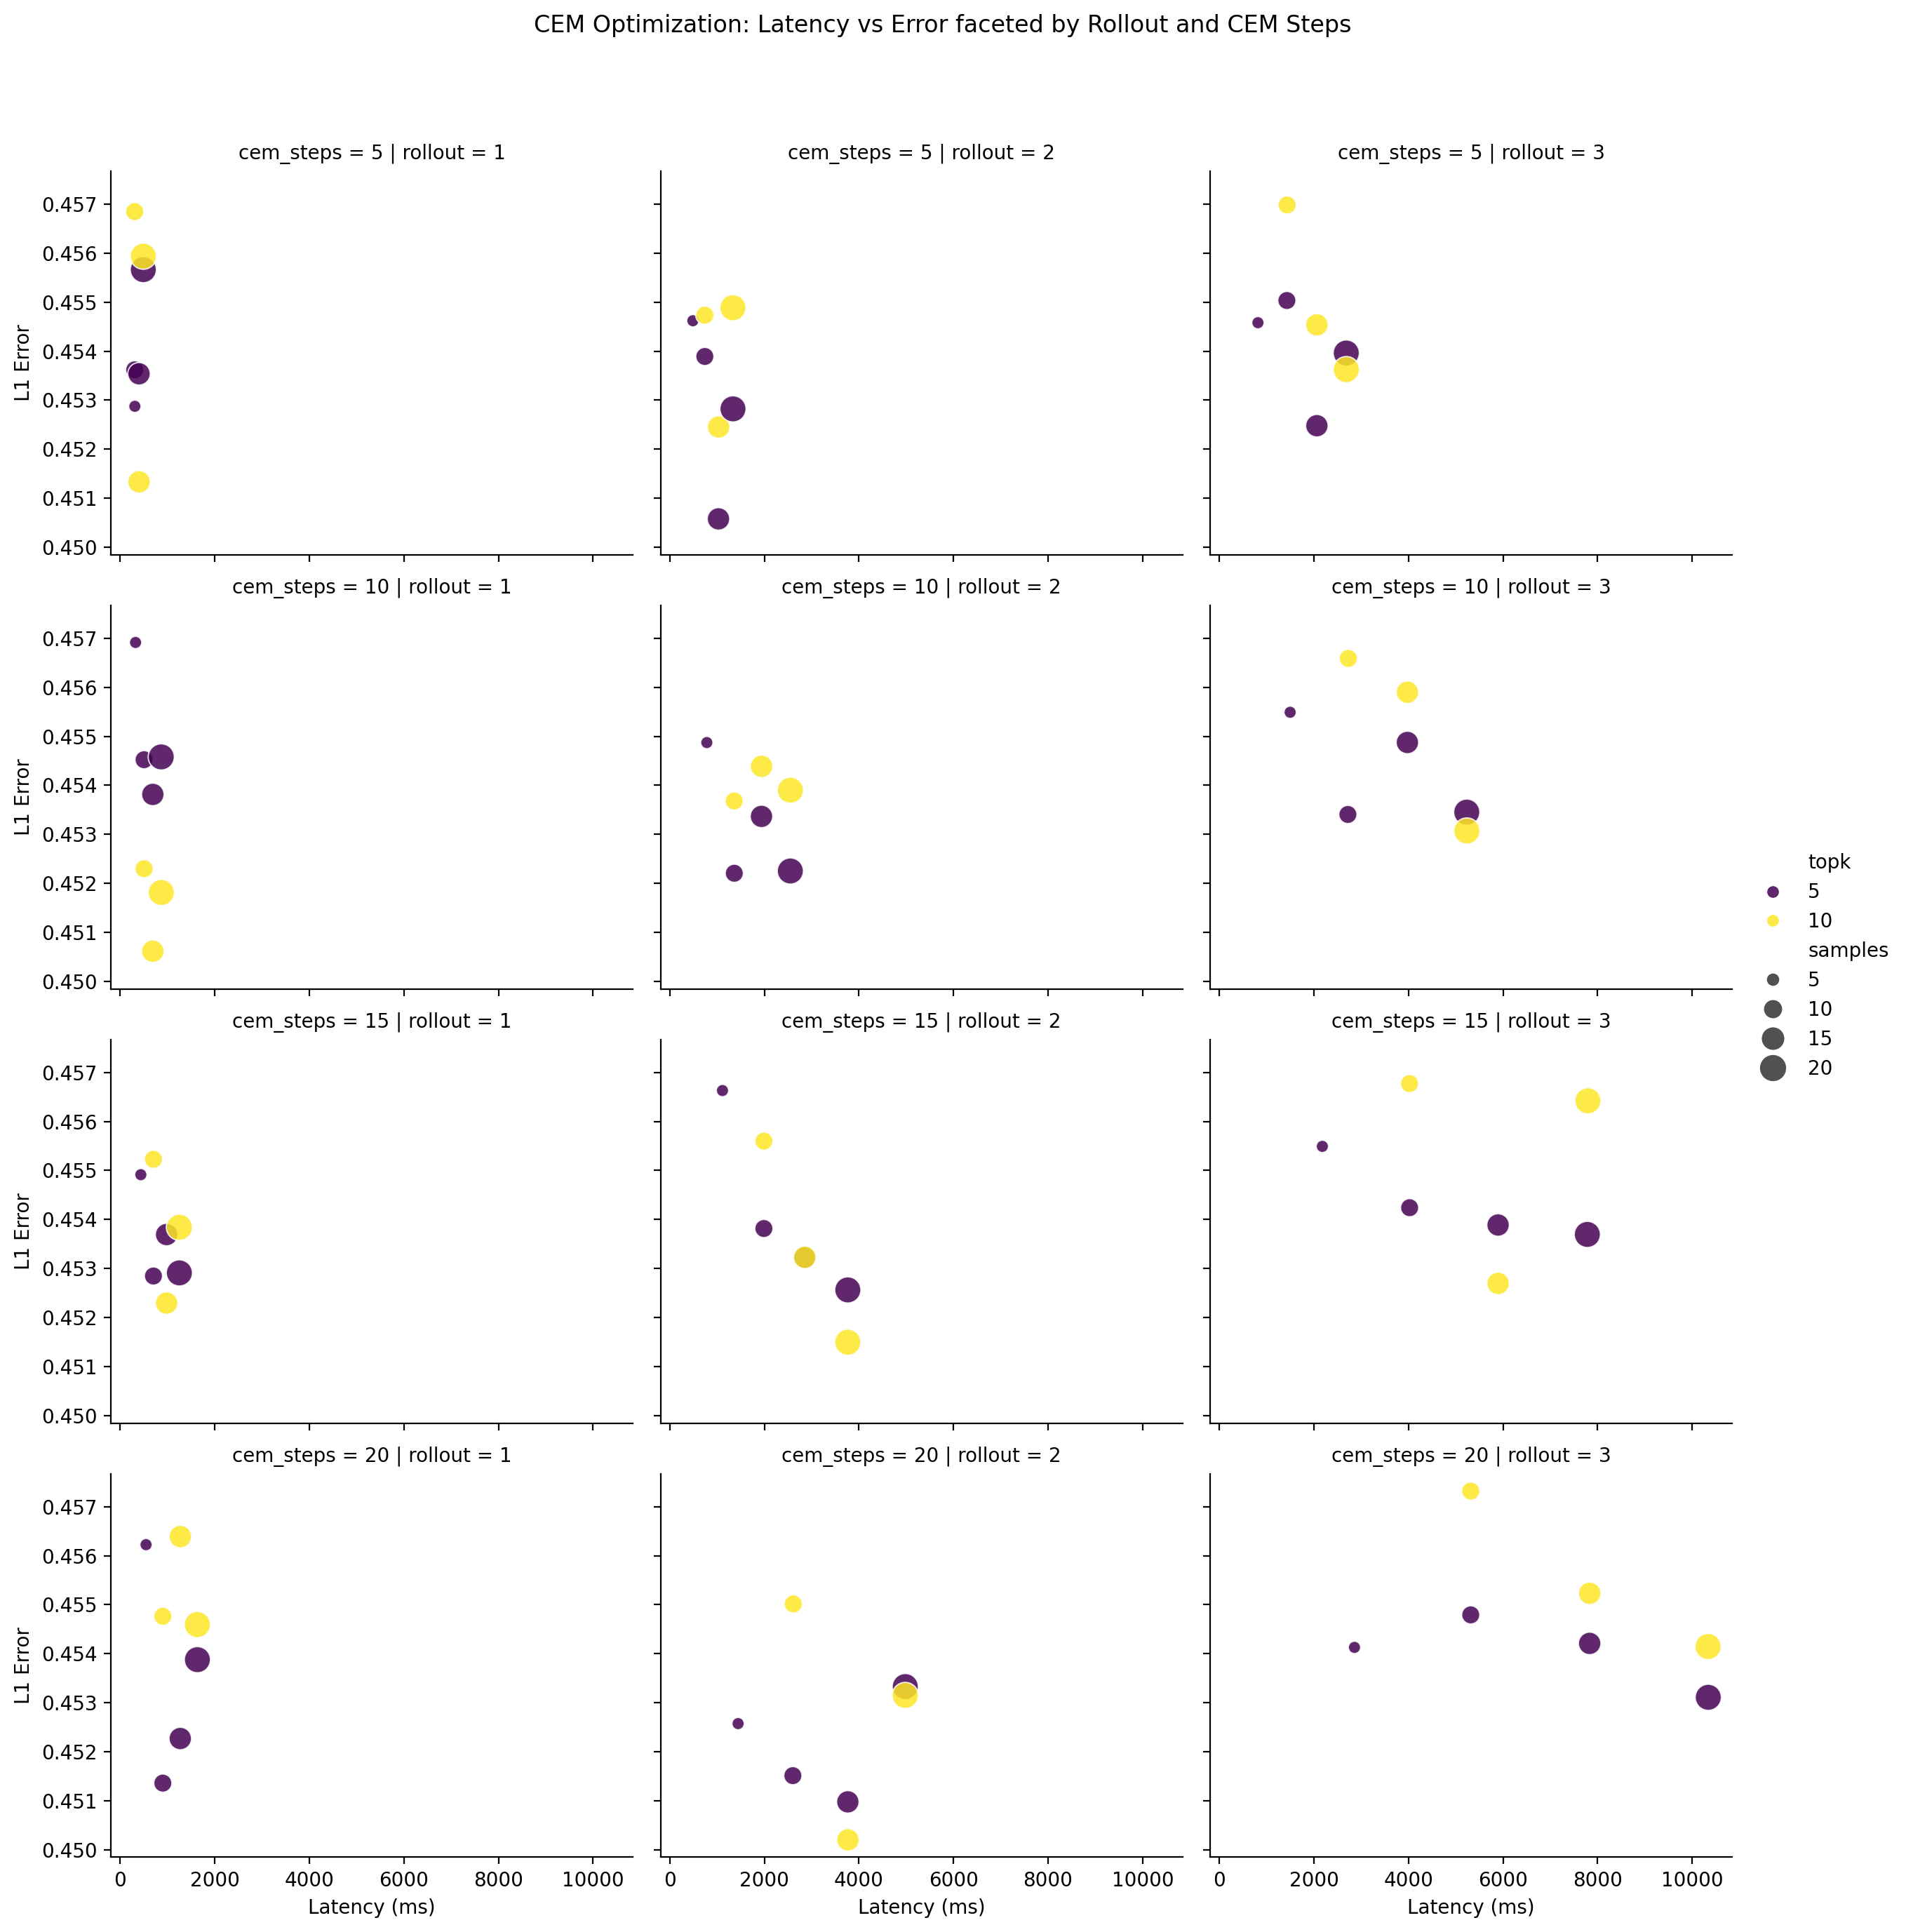

In [10]:
g = sns.relplot(
    data=df_results,
    x="mean_inference_latency_ms",
    y="mean_rep_l1_error",
    col="rollout",  # Split across columns
    row="cem_steps",  # Split across rows
    hue="topk",  # Distinguish within subplot
    size="samples",
    sizes=(40, 180),
    palette="viridis",
    alpha=0.85,
    kind="scatter",
    height=3.5,
    aspect=1.2,
)

g.set_axis_labels("Latency (ms)", "L1 Error")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(
    "CEM Optimization: Latency vs Error faceted by Rollout and CEM Steps"
)
plt.show()

### Pareto Frontier (L1 Error)

R:1, C:5, S:10, K:10
R:1, C:5, S:10, K:5
R:1, C:5, S:5, K:5
R:1, C:5, S:15, K:10
R:1, C:10, S:15, K:10
R:2, C:5, S:15, K:5
R:2, C:20, S:15, K:10


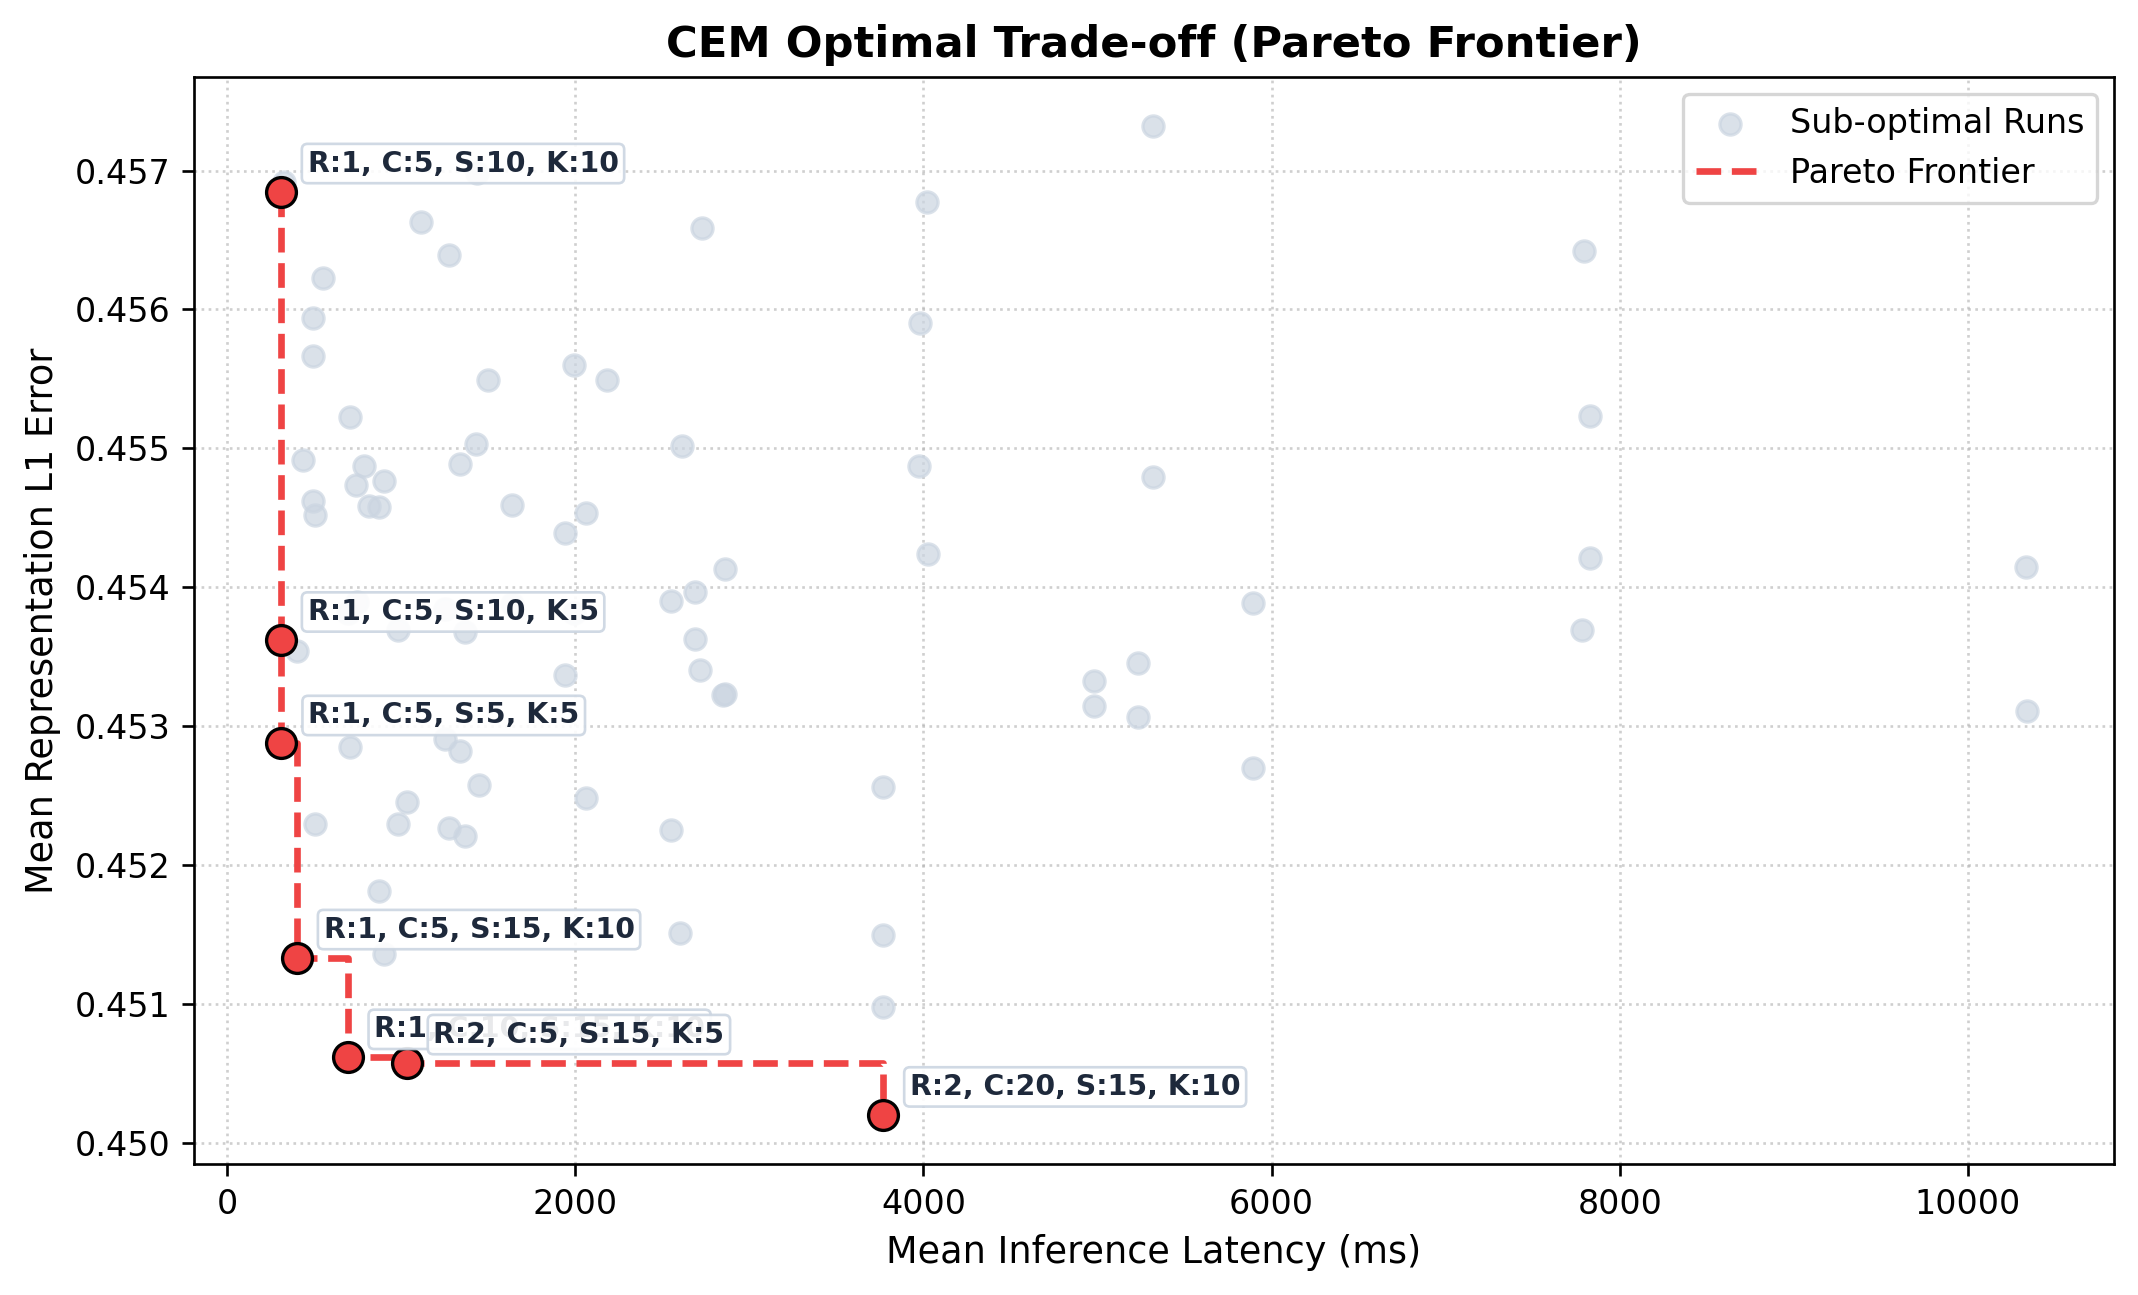

In [11]:
# 1. Compute the Pareto frontier (strictly minimizing latency & L1 error)
df_sorted = df_results.sort_values(
    by=["mean_inference_latency_ms", "mean_rep_l1_error"]
)
pareto_rows = []
min_error = float("inf")

for _, row in df_sorted.iterrows():
    if row["mean_rep_l1_error"] < min_error:
        pareto_rows.append(row)
        min_error = row["mean_rep_l1_error"]

df_pareto = pd.DataFrame(pareto_rows)

# 2. Plot
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# All runs in the background
ax.scatter(
    df_results["mean_inference_latency_ms"],
    df_results["mean_rep_l1_error"],
    color="#cbd5e1",
    s=40,
    alpha=0.7,
    label="Sub-optimal Runs",
    zorder=2,
)

# Pareto frontier line and markers
ax.step(
    df_pareto["mean_inference_latency_ms"],
    df_pareto["mean_rep_l1_error"],
    where="post",
    color="#ef4444",
    linewidth=2,
    linestyle="--",
    label="Pareto Frontier",
    zorder=3,
)
ax.scatter(
    df_pareto["mean_inference_latency_ms"],
    df_pareto["mean_rep_l1_error"],
    color="#ef4444",
    s=80,
    edgecolor="black",
    linewidth=1,
    zorder=4,
)

# 3. Label only the Pareto optimal configurations
for _, row in df_pareto.iterrows():
    tag = f"R:{int(row['rollout'])}, C:{int(row['cem_steps'])}, S:{int(row['samples'])}, K:{int(row['topk'])}"
    print(f"{tag}")
    ax.annotate(
        tag,
        (row["mean_inference_latency_ms"], row["mean_rep_l1_error"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="semibold",
        color="#1e293b",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="#cbd5e1",
            lw=0.8,
            alpha=0.9,
        ),
        zorder=5,
    )

# Styling
ax.set_title(
    "CEM Optimal Trade-off (Pareto Frontier)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
ax.set_ylabel("Mean Representation L1 Error", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

### Facet Grid (Pose Error)

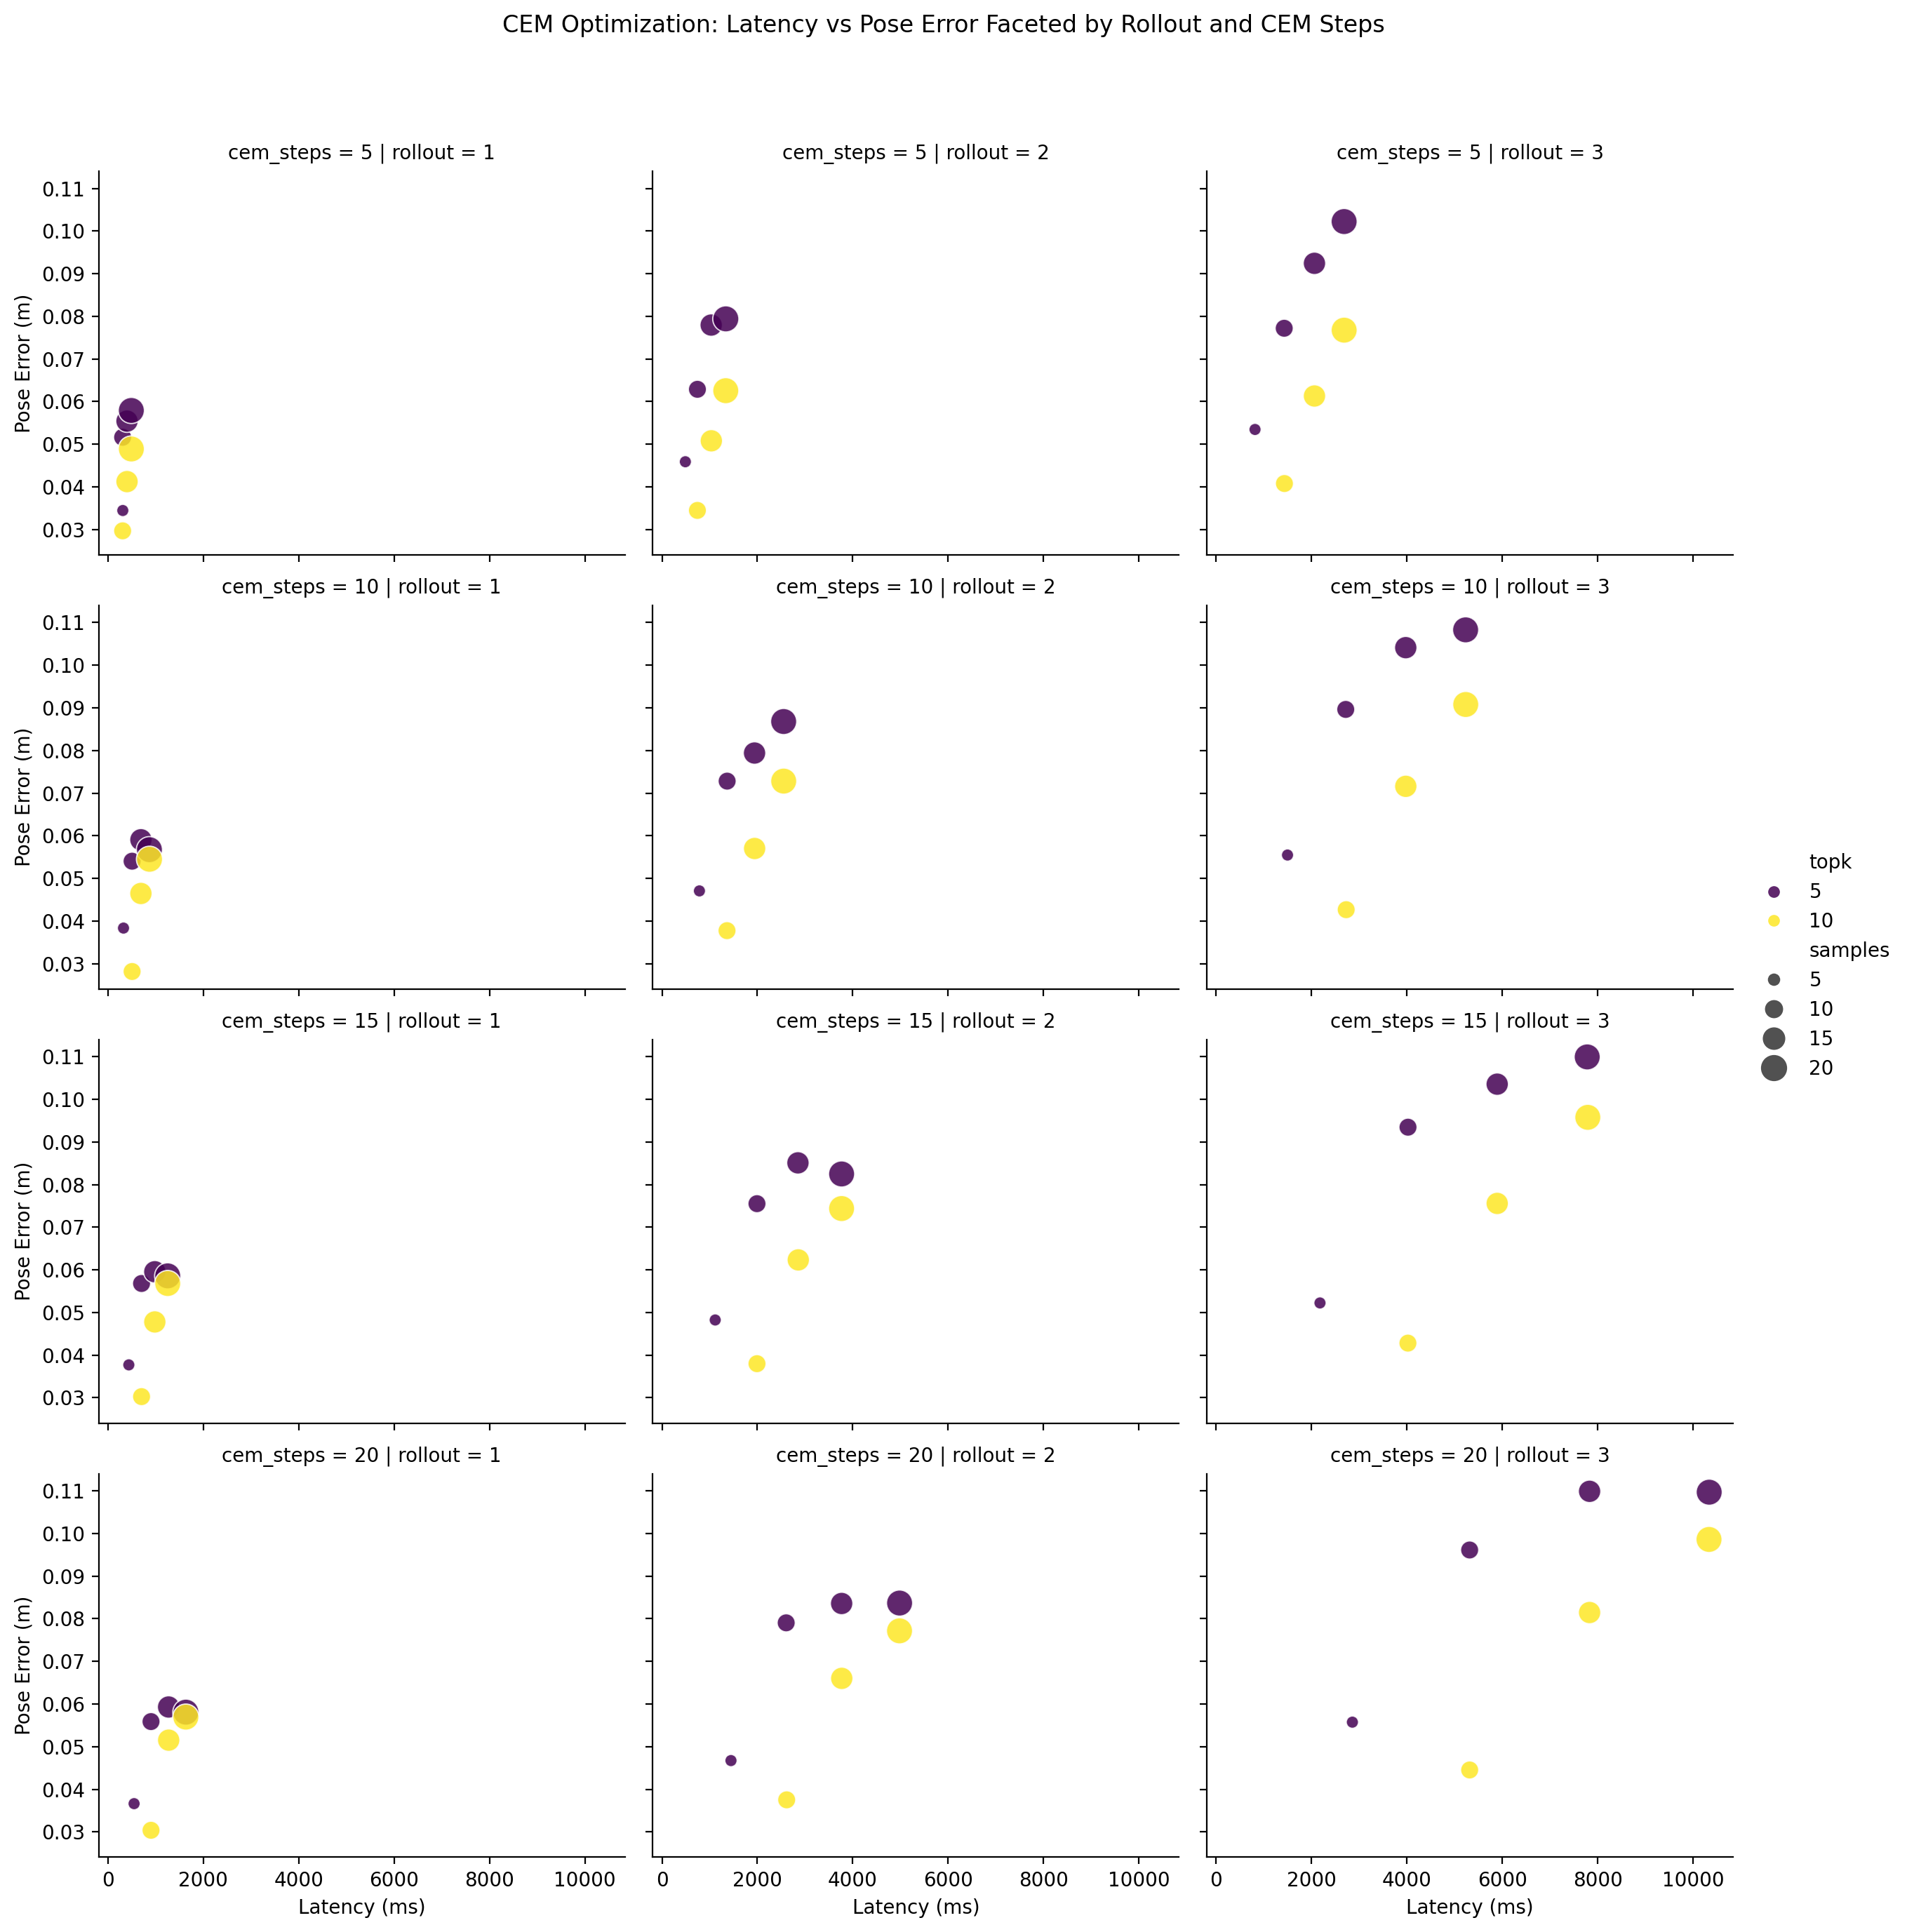

In [12]:
g = sns.relplot(
    data=df_results,
    x="mean_inference_latency_ms",
    y="mean_pose_error_m",
    col="rollout",  # Split across columns
    row="cem_steps",  # Split across rows
    hue="topk",  # Distinguish within subplot
    size="samples",
    sizes=(40, 180),
    palette="viridis",
    alpha=0.85,
    kind="scatter",
    height=3.5,
    aspect=1.2,
)

g.set_axis_labels("Latency (ms)", "Pose Error (m)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(
    "CEM Optimization: Latency vs Pose Error Faceted by Rollout and CEM Steps"
)
plt.show()

### Pareto Frontier (Pose Error)

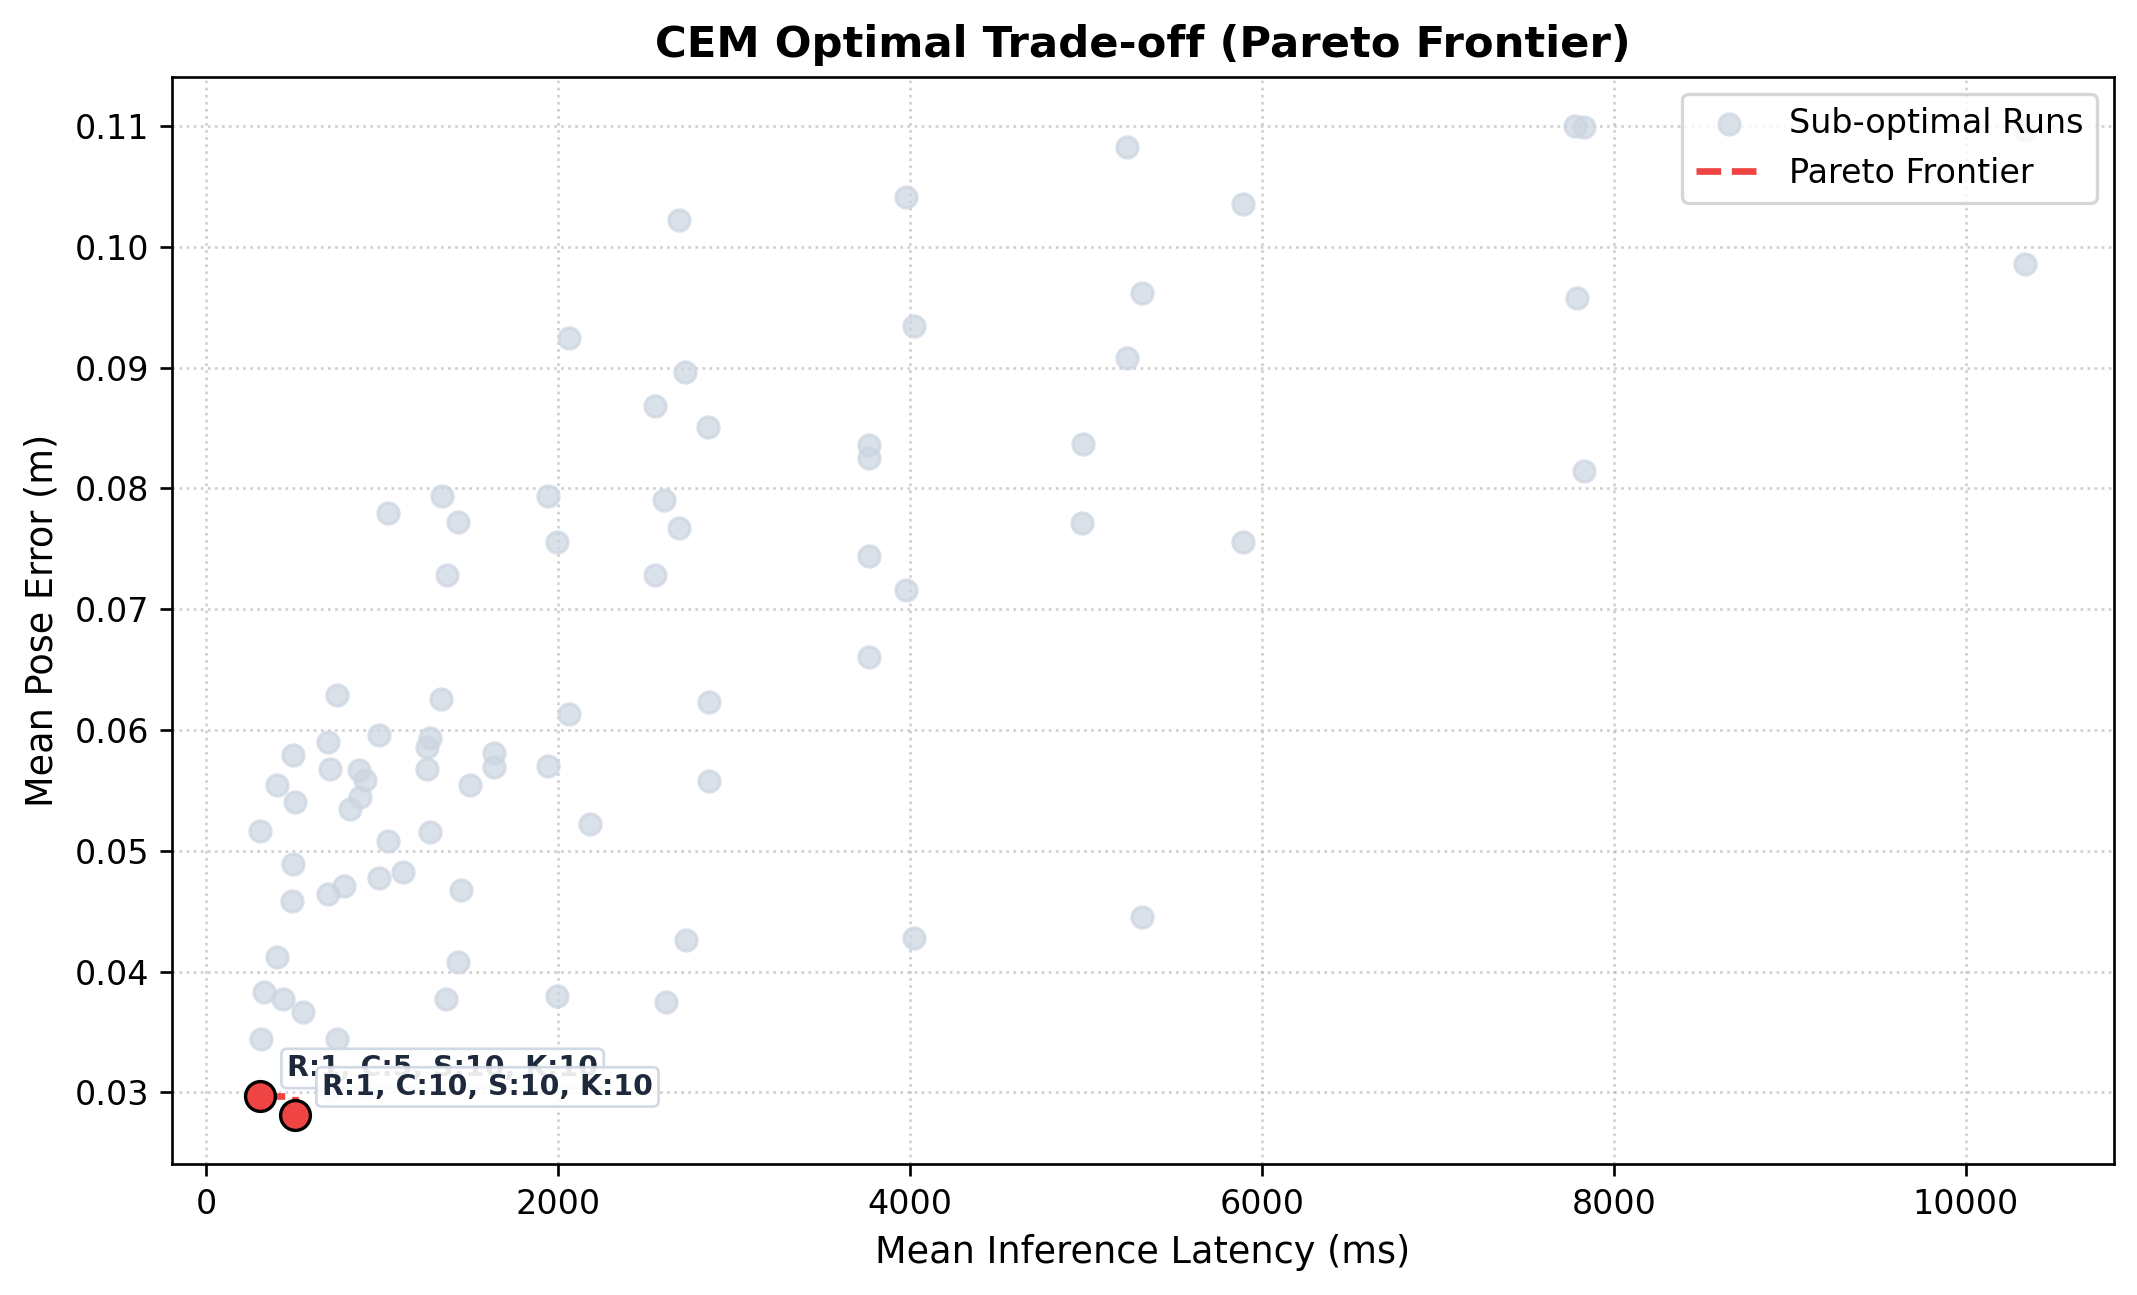

In [13]:
# 1. Compute the Pareto frontier (strictly minimizing latency & L1 error)
df_sorted = df_results.sort_values(
    by=["mean_inference_latency_ms", "mean_pose_error_m"]
)
pareto_rows = []
min_error = float("inf")

for _, row in df_sorted.iterrows():
    if row["mean_pose_error_m"] < min_error:
        pareto_rows.append(row)
        min_error = row["mean_pose_error_m"]

df_pareto = pd.DataFrame(pareto_rows)

# 2. Plot
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# All runs in the background
ax.scatter(
    df_results["mean_inference_latency_ms"],
    df_results["mean_pose_error_m"],
    color="#cbd5e1",
    s=40,
    alpha=0.7,
    label="Sub-optimal Runs",
    zorder=2,
)

# Pareto frontier line and markers
ax.step(
    df_pareto["mean_inference_latency_ms"],
    df_pareto["mean_pose_error_m"],
    where="post",
    color="#ef4444",
    linewidth=2,
    linestyle="--",
    label="Pareto Frontier",
    zorder=3,
)
ax.scatter(
    df_pareto["mean_inference_latency_ms"],
    df_pareto["mean_pose_error_m"],
    color="#ef4444",
    s=80,
    edgecolor="black",
    linewidth=1,
    zorder=4,
)

# 3. Label only the Pareto optimal configurations
for _, row in df_pareto.iterrows():
    tag = f"R:{int(row['rollout'])}, C:{int(row['cem_steps'])}, S:{int(row['samples'])}, K:{int(row['topk'])}"
    ax.annotate(
        tag,
        (row["mean_inference_latency_ms"], row["mean_pose_error_m"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=8.5,
        fontweight="semibold",
        color="#1e293b",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="#cbd5e1",
            lw=0.8,
            alpha=0.9,
        ),
        zorder=5,
    )

# Styling
ax.set_title(
    "CEM Optimal Trade-off (Pareto Frontier)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
ax.set_ylabel("Mean Pose Error (m)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

### Parallel Coordinate Plots

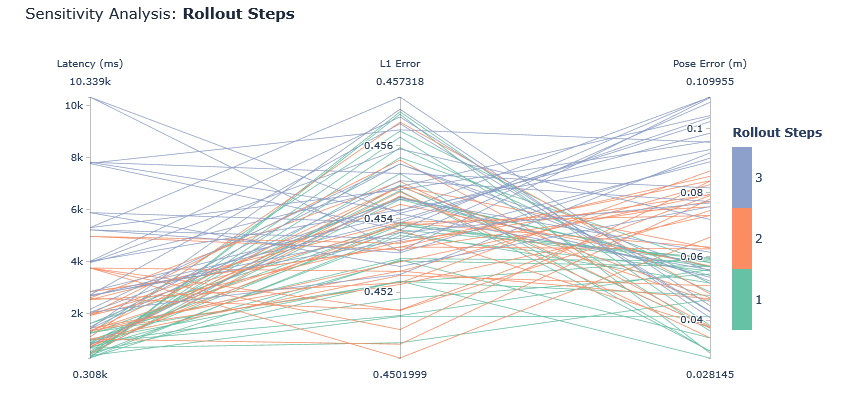

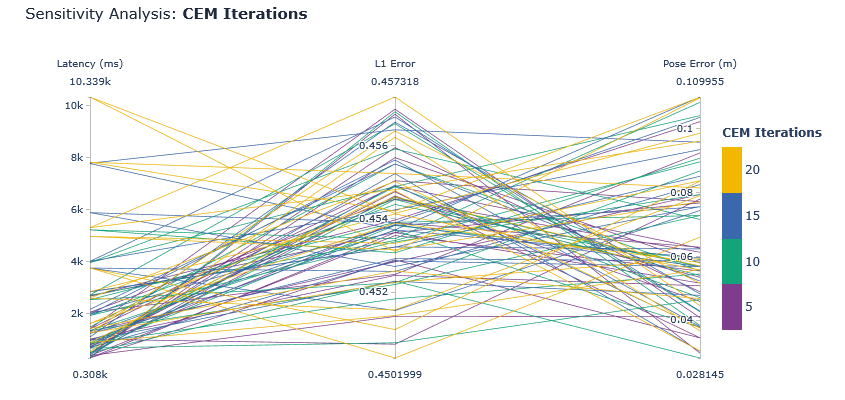

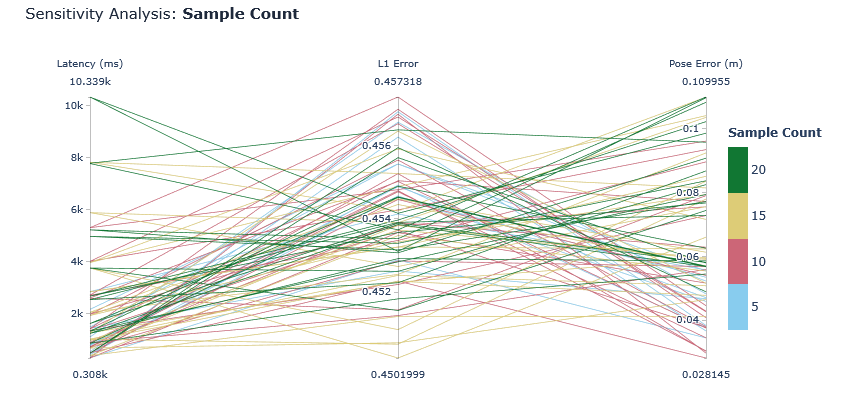

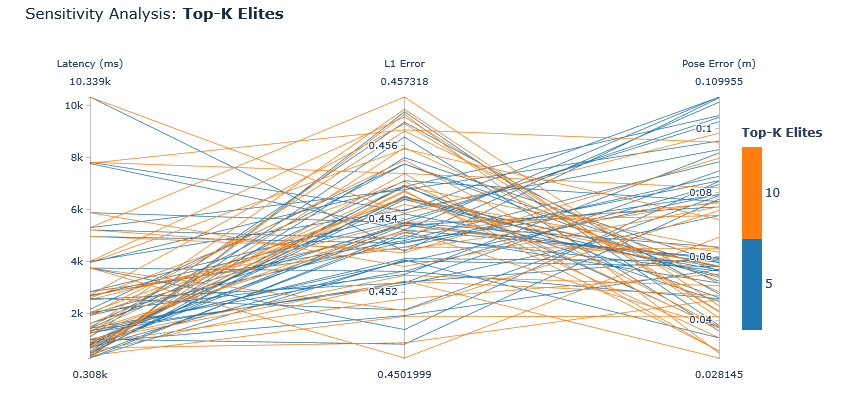

In [14]:
import plotly.express as px
import plotly.graph_objects as go

df = df_results.copy()

params = ["rollout", "cem_steps", "samples", "topk"]
param_titles = {
    "rollout": "Rollout Steps",
    "cem_steps": "CEM Iterations",
    "samples": "Sample Count",
    "topk": "Top-K Elites",
}

# Qualitative discrete palettes (distinct colors with high contrast)
discrete_palettes = {
    "rollout": px.colors.qualitative.Set2,
    "cem_steps": px.colors.qualitative.Bold,
    "samples": px.colors.qualitative.Safe,
    "topk": px.colors.qualitative.D3,
}

# Shared objective ranges
metric_ranges = {
    "Latency (ms)": [
        float(df["mean_inference_latency_ms"].min()),
        float(df["mean_inference_latency_ms"].max()),
    ],
    "L1 Error": [
        float(df["mean_rep_l1_error"].min()),
        float(df["mean_rep_l1_error"].max()),
    ],
    "Pose Error (m)": [
        float(df["mean_pose_error_m"].min()),
        float(df["mean_pose_error_m"].max()),
    ],
}


def build_discrete_colorscale(unique_vals, palette):
    """Builds a discrete stepped colorscale matching exact discrete values."""
    n = len(unique_vals)
    colors = [palette[i % len(palette)] for i in range(n)]
    scale = []
    for i in range(n):
        low = i / n
        high = (i + 1) / n
        scale.append([low, colors[i]])
        scale.append([high, colors[i]])
    return scale, colors


for p in params:
    unique_vals = sorted(df[p].unique())
    n_vals = len(unique_vals)

    # Map each distinct parameter value to an integer index [0, 1, ..., n-1]
    val_to_idx = {val: i for i, val in enumerate(unique_vals)}
    color_indices = df[p].map(val_to_idx)

    stepped_scale, _ = build_discrete_colorscale(
        unique_vals, discrete_palettes[p]
    )

    # Position ticks right in the middle of each discrete colored band
    tick_positions = [(i + 0.5) for i in range(n_vals)]
    tick_labels = [str(val) for val in unique_vals]

    dimensions = [
        dict(
            label="Latency (ms)",
            values=df["mean_inference_latency_ms"],
            range=metric_ranges["Latency (ms)"],
        ),
        dict(
            label="L1 Error",
            values=df["mean_rep_l1_error"],
            range=metric_ranges["L1 Error"],
        ),
        dict(
            label="Pose Error (m)",
            values=df["mean_pose_error_m"],
            range=metric_ranges["Pose Error (m)"],
        ),
    ]

    fig = go.Figure(
        data=go.Parcoords(
            line=dict(
                color=color_indices,
                colorscale=stepped_scale,
                cmin=0,
                cmax=n_vals,
                showscale=True,
                colorbar=dict(
                    title=dict(
                        text=f"<b>{param_titles[p]}</b>",
                        side="top",
                        font=dict(size=12),
                    ),
                    tickvals=tick_positions,
                    ticktext=tick_labels,
                    thickness=20,
                    len=0.85,
                ),
            ),
            dimensions=dimensions,
        )
    )

    fig.update_layout(
        title=dict(
            text=f"Sensitivity Analysis: <b>{param_titles[p]}</b>",
            font=dict(size=15, color="#1e293b"),
            x=0.03,
            y=0.98,  # Anchors title at the top
            xanchor="left",
            yanchor="top",
        ),
        height=400,
        width=950,
        template="plotly_white",
        margin=dict(l=90, r=110, t=95, b=40),  # t=95 prevents label collision
    )

    fig.show()

### Boxplot + Stripplot

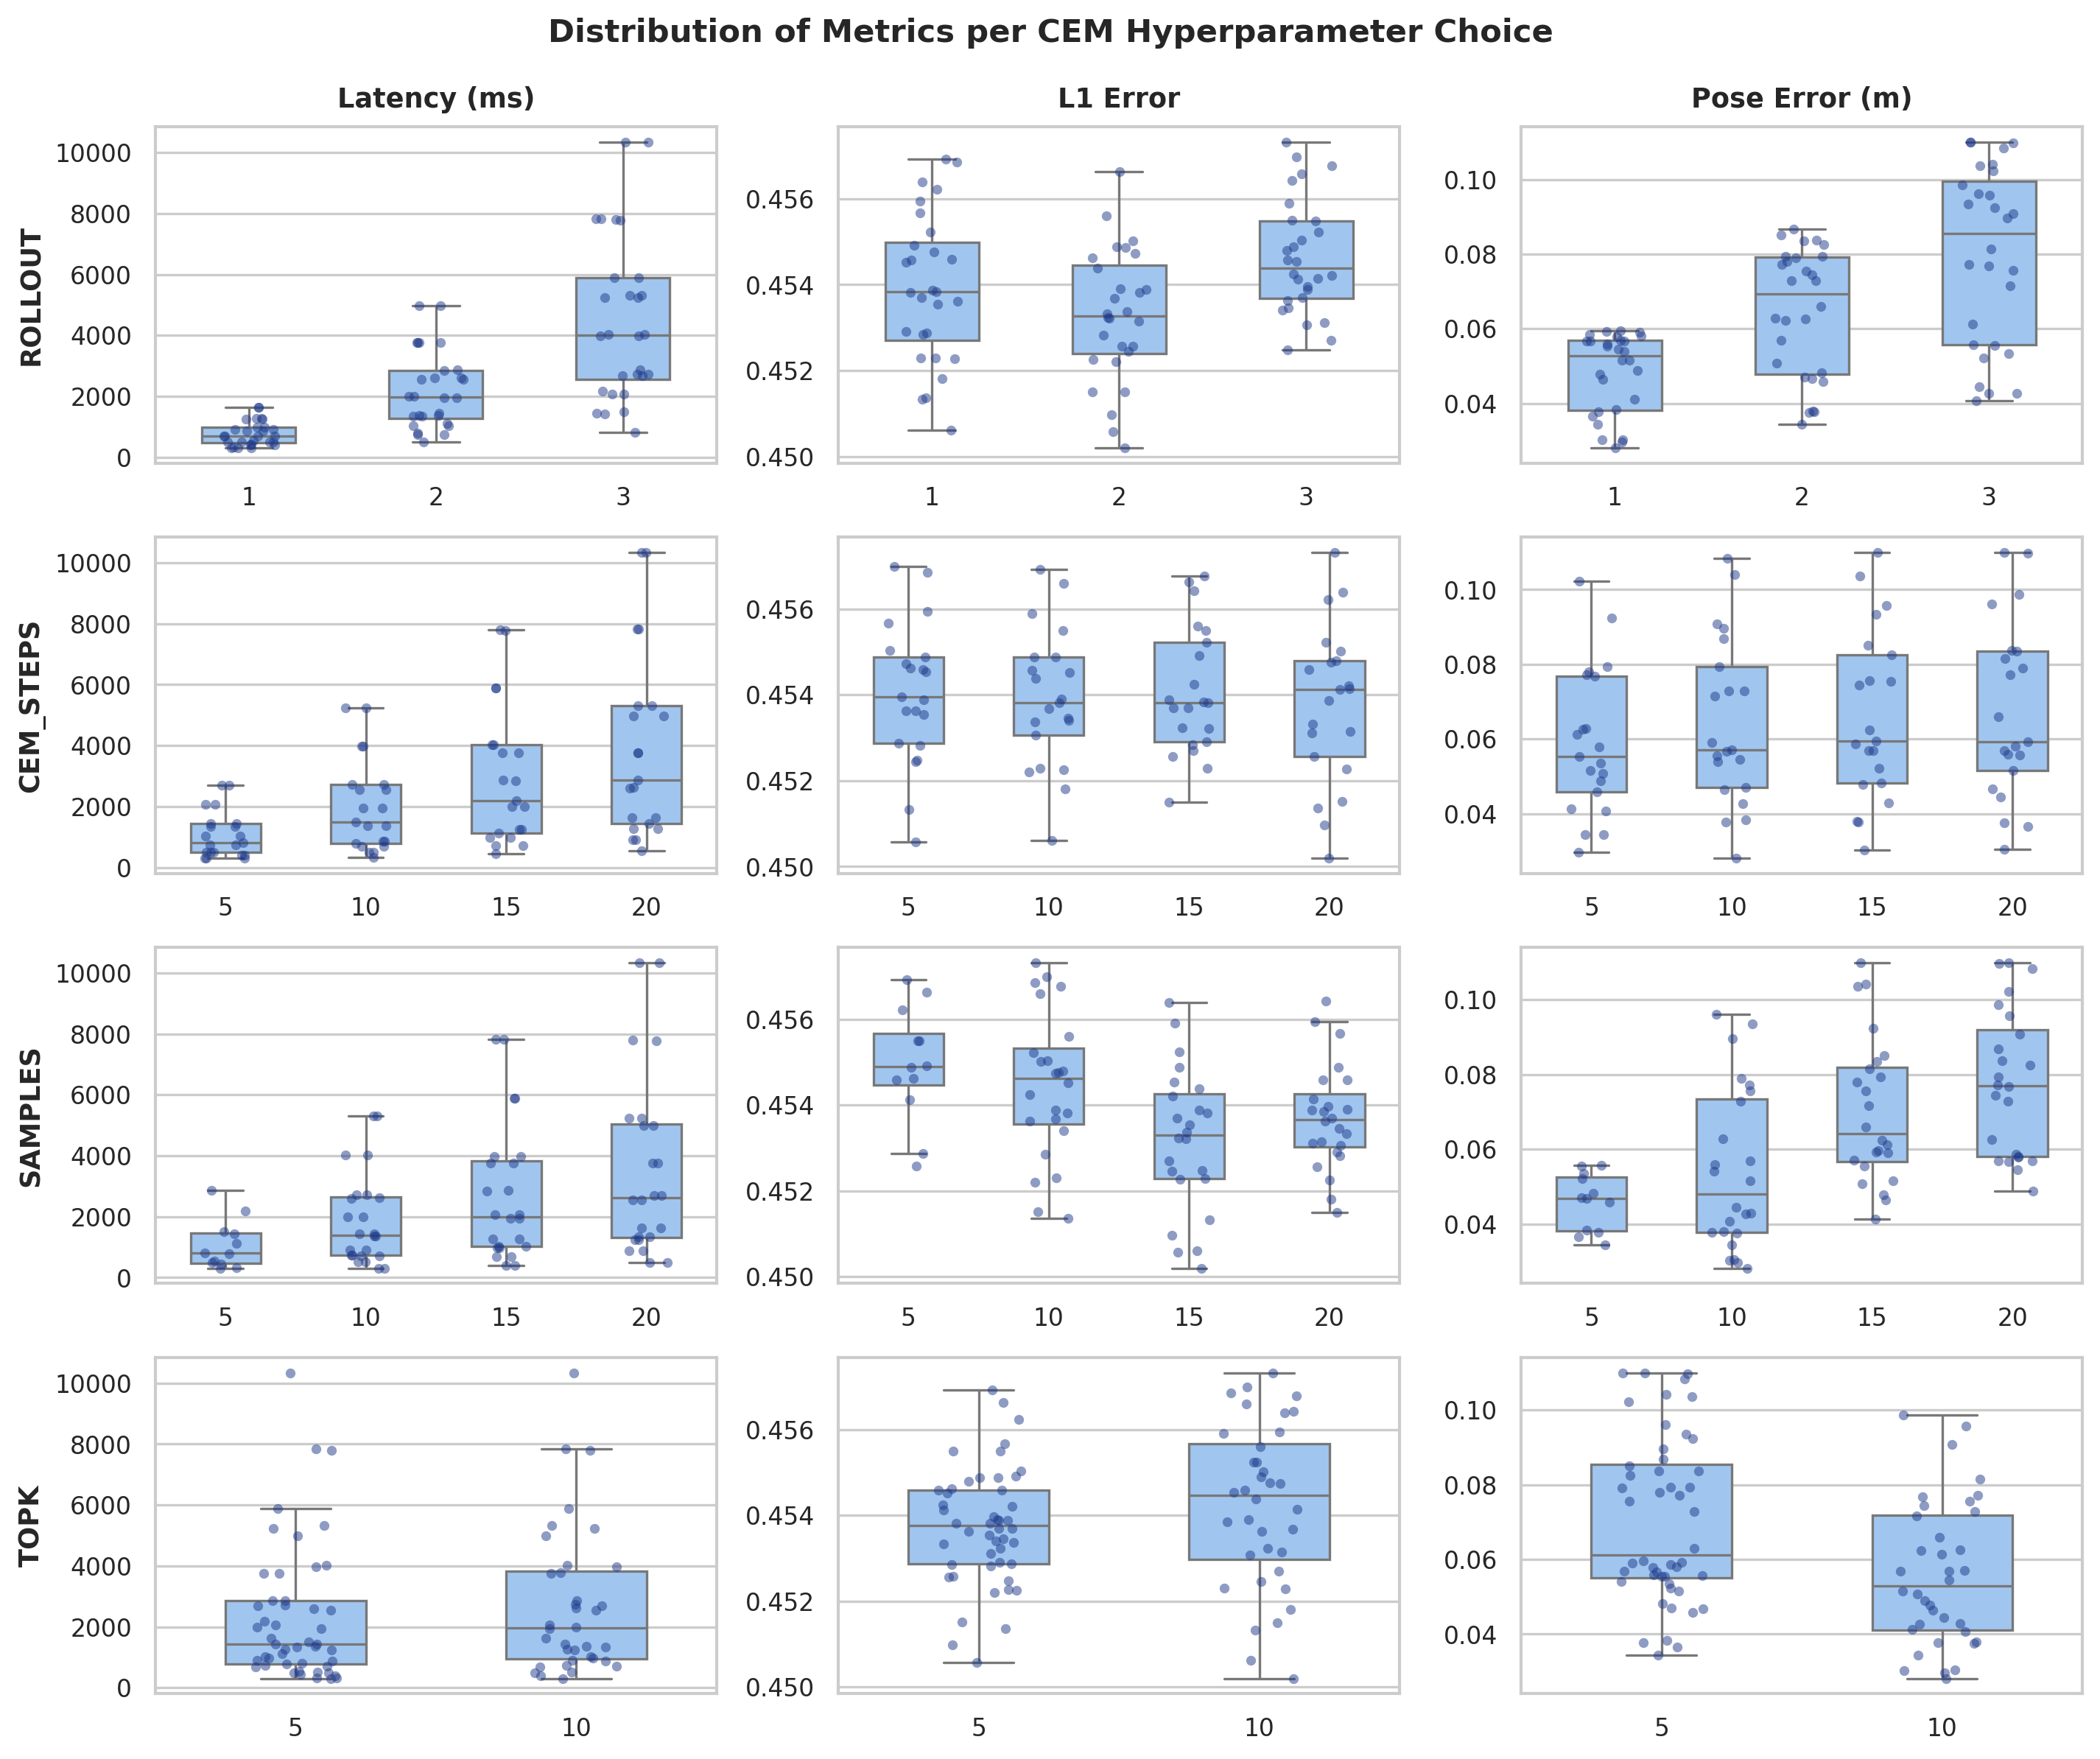

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)

params = ["rollout", "cem_steps", "samples", "topk"]
metrics = [
    ("mean_inference_latency_ms", "Latency (ms)"),
    ("mean_rep_l1_error", "L1 Error"),
    ("mean_pose_error_m", "Pose Error (m)"),
]

fig, axes = plt.subplots(len(params), len(metrics), figsize=(12, 10), dpi=120)

for r, p in enumerate(params):
    for c, (m_col, m_name) in enumerate(metrics):
        ax = axes[r, c]
        # Boxplot with overlay points to show distribution and sample density
        sns.boxplot(
            data=df_results,
            x=p,
            y=m_col,
            ax=ax,
            color="#93c5fd",
            fliersize=0,
            width=0.5,
        )
        sns.stripplot(
            data=df_results,
            x=p,
            y=m_col,
            ax=ax,
            color="#1e3a8a",
            alpha=0.5,
            jitter=0.15,
            size=4,
        )

        if r == 0:
            ax.set_title(m_name, fontsize=11, fontweight="bold", pad=8)
        if c == 0:
            ax.set_ylabel(f"{p.upper()}", fontsize=11, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

plt.suptitle(
    "Distribution of Metrics per CEM Hyperparameter Choice",
    fontsize=13,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()